# Workshop 1 — Inside the transformer (live)

We open the model together: **I run, you predict and react.** Three things to watch for —

1. **Meaning is geometry** (embeddings)
2. **Words look at each other** (attention)
3. **The output is a roll of the dice** (probabilities + temperature)

*(The detailed, self-paced version is `workshop1_extended.ipynb`.)*

## Setup 1 — load the model

Four objects: a **tokenizer** (text ↔ ids), the **model** (the network), and an **embedding
table** scaled to unit length so a dot product reads as cosine similarity.

In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()                                  # quiet the download warnings

device = "cuda" if torch.cuda.is_available() else "cpu"           # use the GPU if there is one
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B")      # turns text into token ids and back
model = AutoModelForCausalLM.from_pretrained(                     # the network itself
    "Qwen/Qwen3-0.6B", attn_implementation="eager").to(device).eval()
#   eager attention -> we can read the attention weights ;  .eval() -> inference mode

# every token's embedding, scaled to length 1, so embed_unit[a] · embed_unit[b] = cosine similarity
embed_unit = F.normalize(model.get_input_embeddings().weight.float(), dim=1)
print("ready on", device)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

ready on cuda


## Setup 2 — compute helpers (model → numbers)

Each one does a single thing and **returns plain numbers** — no drawing here. `@torch.no_grad()`
means: don't track gradients — we're only looking, not learning.

In [21]:
@torch.no_grad()
def token_pieces(text):
    ids = tokenizer(text, add_special_tokens=False).input_ids     # text -> token ids
    return [tokenizer.decode([i]) for i in ids]                   # each id -> its piece of text

@torch.no_grad()
def word_vector(word):
    ids = tokenizer(word, add_special_tokens=False).input_ids
    return model.get_input_embeddings().weight[ids].float().mean(0)   # average the word's token embeddings

@torch.no_grad()
def neighbors(word, k=8):
    i = tokenizer(word, add_special_tokens=False).input_ids[0]    # the word's first token id
    sims = embed_unit @ embed_unit[i]                            # cosine similarity to every token
    return [tokenizer.decode([j]).strip() for j in sims.topk(k + 1).indices[1:].tolist()]  # k closest (skip itself)

@torch.no_grad()
def analogy(a, b, c, k=5):
    target = word_vector(a) - word_vector(b) + word_vector(c)     # e.g. king - man + woman
    sims = embed_unit @ F.normalize(target, dim=0)               # similarity to every token
    ignore = {a.strip().lower(), b.strip().lower(), c.strip().lower()}
    hits = [tokenizer.decode([j]).strip() for j in sims.topk(k + 12).indices.tolist()]
    return [w for w in hits if w.lower() not in ignore][:k]       # drop the input words

@torch.no_grad()
def attention_weights(text, layer=6, head=1):
    ids = tokenizer(text, return_tensors="pt").input_ids.to(device)
    pieces = [t.lstrip("Ġ") for t in tokenizer.convert_ids_to_tokens(ids[0])]
    A = model(ids, output_attentions=True).attentions[layer][0, head]   # one head's attention matrix
    return pieces, A.float().cpu().numpy()

@torch.no_grad()
def next_token_probs(prompt, T=1.0, k=10):
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    logits = model(ids).logits[0, -1].float()                    # scores for the next token (float32 for plotting)
    probs = F.softmax(logits / T, dim=-1)                       # scores -> probabilities (T reshapes them)
    top = probs.topk(k)
    words = [tokenizer.decode([i]) for i in top.indices.tolist()]
    return words, top.values.cpu().numpy()

## Setup 3 — draw helpers (numbers → picture)

Pure matplotlib — they never touch the model, they just plot what the compute helpers returned.

In [10]:
def plot_heatmap(tokens, A, title=""):
    plt.figure(figsize=(7, 6)); plt.imshow(A, cmap="viridis")
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    plt.xlabel("attending TO"); plt.title(title)
    plt.colorbar(fraction=0.046); plt.tight_layout(); plt.show()

def plot_bars(words, probs, title=""):
    y = list(range(len(words)))[::-1]
    plt.figure(figsize=(8, 4)); plt.barh(y, probs)
    plt.yticks(y, [repr(w) for w in words]); plt.xlim(0, 1)
    plt.title(title); plt.tight_layout(); plt.show()

## Aside — what is `@`?

It means two unrelated things here. Above a `def` it's a **decorator** (it wrapped our compute helpers
in "no gradients"). *Between two values* it's **matrix multiplication** — the one doing the real work:
`neighbors` runs `embed_unit @ embed_unit[i]`, dotting *every* token's embedding with one word's to get
all ~150k similarities in a single `@`. Let's prove `@` is just dot products done by hand:

In [11]:
# matrix @ vector = each ROW of the matrix, dotted with the vector
M = torch.tensor([[1., 0.],      # 3 "tokens", 2 numbers each
                  [0., 1.],
                  [1., 1.]])
v = torch.tensor([2., 3.])       # one "word" vector

with_operator = M @ v                                          # the @ operator — all rows at once
by_hand = torch.tensor([(row * v).sum().item() for row in M])  # row · v, one at a time
print("M @ v   :", with_operator.tolist())
print("by hand :", by_hand.tolist())
print("same?   :", torch.allclose(with_operator, by_hand))

M @ v   : [2.0, 3.0, 5.0]
by hand : [2.0, 3.0, 5.0]
same?   : True


## 1 · How the model reads — tokens

💬 *Ask the room for a Kazakh word. Type it in and run — watch it shatter into pieces.*

In [12]:
token_pieces("Қазақстан")   # 💬 swap in a word from the room

['Қ', 'аз', 'а', 'қ', 'стан']

## 2 · Meaning is geometry

💬 *"What's similar to* king*?" Take guesses, then reveal the neighbors. Then ask for an analogy
to try before you run it.*

In [13]:
print("neighbors of king:  ", neighbors(" king"))
print("king - man + woman = ", analogy(" king", " man", " woman"))

neighbors of king:   ['King', 'King', 'kings', 'KING', '国王', 'queen', 'king', 'kingdom']
king - man + woman =  ['queen', 'kings', 'Queen', 'queen', 'Queen']


## 3 · Words look at each other — attention

💬 *Read the sentence aloud. **Take a vote:** does "it" mean the **animal** or the **street**?
Only then run — the "it" row lights up on "animal."*

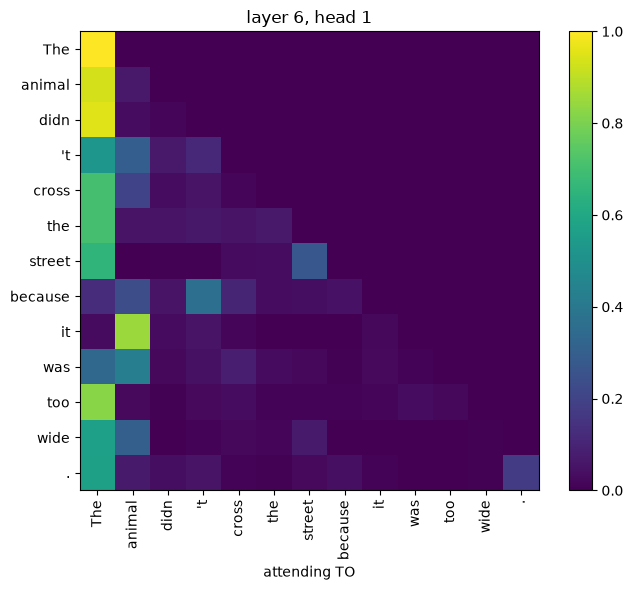

In [23]:
tokens, A = attention_weights("The animal didn't cross the street because it was too wide.")
plot_heatmap(tokens, A, title="layer 6, head 1")

💬 *"Surely if I change the last word, 'it' changes its mind?" Check it — but note **"wide" comes
*after* "it".** Run and read the two numbers aloud.*

In [24]:
tokens, A_tired = attention_weights("The animal didn't cross the street because it was too tired.")
_,      A_wide  = attention_weights("The animal didn't cross the street because it was too wide.")
it, animal = tokens.index("it"), tokens.index("animal")
print("it -> animal   (…too tired):", round(float(A_tired[it, animal]), 3))
print("it -> animal   (…too wide): ", round(float(A_wide[it, animal]), 3))

it -> animal   (…too tired): 0.848
it -> animal   (…too wide):  0.848


**Identical.** "it" never saw the adjective — a **decoder can't look at the future** (the causal
mask, live). The "it flips to *street*" trick needs an **encoder** (bidirectional) — the BERT view in
the lecture. Same idea, *different transformer type.*

## 4 · The output is a roll of the dice

💬 *The model never gives one answer — it gives a **distribution**, and its **shape** shows how
**constrained** the next word is. One prompt with a single right answer, then one with many. (The
spread one isn't "confused" — every bar is a real colour; it just can't know which one* you *like.)*

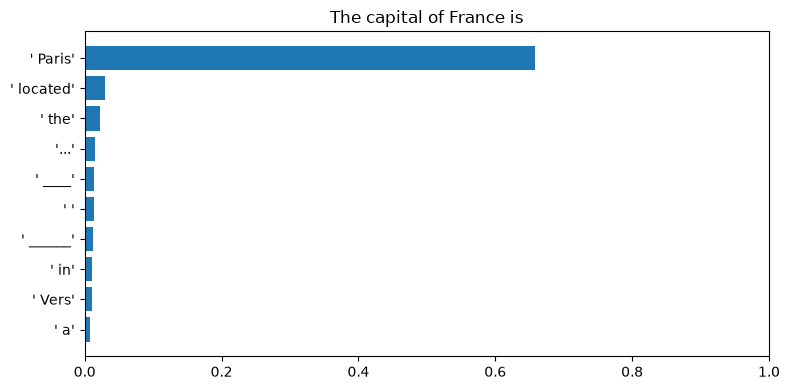

In [25]:
words, probs = next_token_probs("The capital of France is")    # one right answer -> a spike
plot_bars(words, probs, title="The capital of France is")

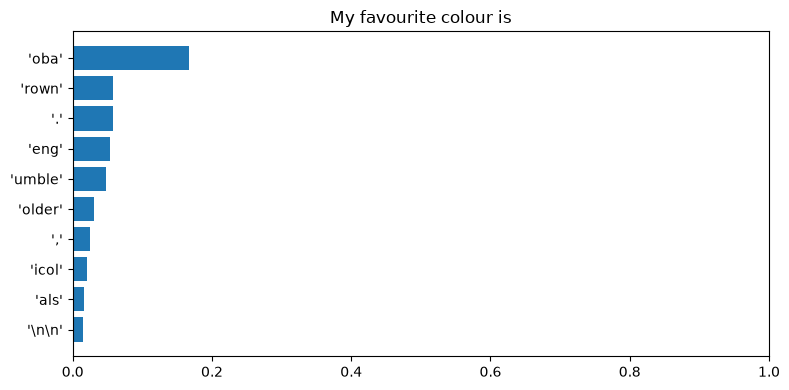

In [29]:
words, probs = next_token_probs("My favourite colour is b")      # many valid answers -> a spread
plot_bars(words, probs, title="My favourite colour is")

💬 *Now crank the temperature — low sharpens the bars, high flattens them. Let them call out when
it goes off the rails.*

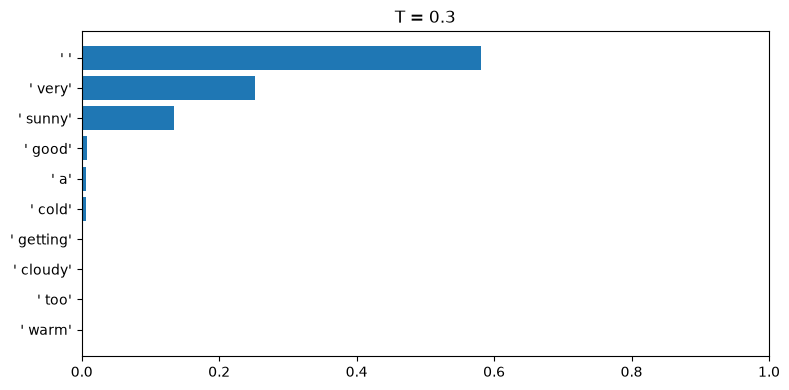

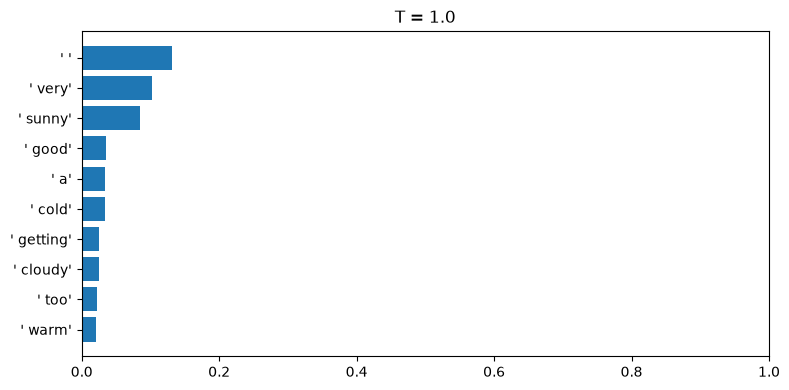

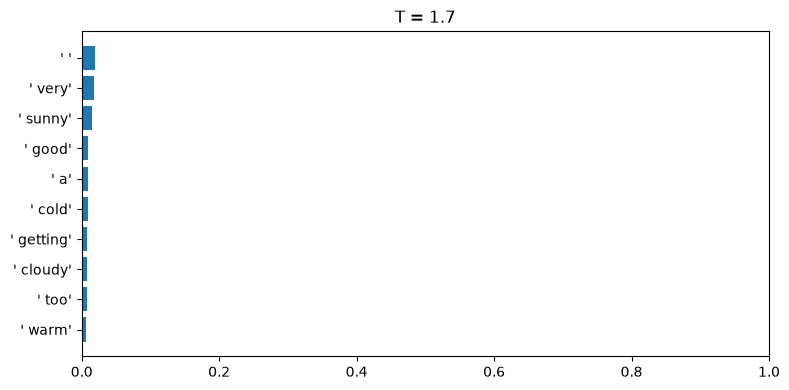

In [27]:
for T in (0.3, 1.0, 1.7):
    words, probs = next_token_probs("The weather today is", T=T)
    plot_bars(words, probs, title=f"T = {T}")

In [28]:
# Optional live slider (updates on release). If it won't move over the tunnel, just call
# next_token_probs / plot_bars directly with the T you want.
from ipywidgets import interact, FloatSlider
def show_temperature(T=1.0):
    words, probs = next_token_probs("The weather today is", T=T)
    plot_bars(words, probs, title=f"T = {T}")
interact(show_temperature, T=FloatSlider(min=0.1, max=2.0, step=0.1, value=1.0, continuous_update=False))

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='T', max=2.0, min=0.1), Outp…

<function __main__.show_temperature(T=1.0)>